# 05 - Clasificación con kNN

En este notebook vamos a aplicar el modelo de clasificación **k-Nearest Neighbors** (`kNN`) al dataset Cora utilizando `scikit-learn`.

El objetivo es comparar el rendimiento del modelo en tres escenarios distintos:

1. Modelo basado únicamente en los atributos originales de palabras.
2. Modelo basado únicamente en métricas relacionales del grafo.
3. Modelo combinado con atributos originales y métricas relacionales.

Como kNN es un algoritmo basado en distancias, es importante normalizar las variables para que ninguna escala domine sobre las demás. Para ello se utilizará `MinMaxScaler`. Además, la comunidad de Louvain se tratará como variable categórica mediante `OneHotEncoder`, ya que sus valores numéricos son etiquetas de comunidad y no magnitudes ordenadas.

La variable objetivo se codificará con `LabelEncoder`, siguiendo la práctica de `scikit-learn`. Esto permite trabajar internamente con clases numéricas y evita problemas al combinar kNN con distintas métricas de distancia.

Finalmente, se aplicará `Pipeline` y `GridSearchCV` para buscar automáticamente los mejores hiperparámetros evitando fuga de datos durante el preprocesado.

## Índice

1. Carga de datos
2. Preparación de conjuntos de atributos
3. División en entrenamiento y prueba
4. Aplicación de kNN base
5. Evaluación de modelos base
6. Optimización con Pipeline y GridSearchCV
7. Conclusiones

## 1. Carga de datos

Cargamos los dos ficheros procesados:

- `cora_content_procesado.csv`: contiene los atributos originales de palabras y la clase temática.
- `cora_metricas_relacionales.csv`: contiene las métricas calculadas a partir del grafo de citaciones.

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [68]:
contenido = pd.read_csv('../data/processed/cora_content_procesado.csv')
metricas = pd.read_csv('../data/processed/cora_metricas_relacionales.csv')

contenido.head()

,articulo_id,palabra_0,palabra_1,palabra_2,palabra_3,palabra_4,palabra_5,palabra_6,palabra_7,palabra_8,...,palabra_1424,palabra_1425,palabra_1426,palabra_1427,palabra_1428,palabra_1429,palabra_1430,palabra_1431,palabra_1432,clase
0,31336,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,Neural_Networks
1,1061127,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,Rule_Learning
2,1106406,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
3,13195,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
4,37879,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Probabilistic_Methods


In [69]:
metricas.head()

,articulo_id,degree,degree_centrality,betweenness_centrality,closeness_centrality,clustering_coefficient,pagerank,louvain_community,clase
0,1033,5,0.001847,0.002430,0.181710,0.100000,0.000212,21,Genetic_Algorithms
1,35,168,0.062061,0.232488,0.222769,0.011406,0.025159,21,Genetic_Algorithms
2,103482,6,0.002216,0.004510,0.186238,0.133333,0.000497,3,Neural_Networks
3,103515,11,0.004064,0.001681,0.180501,0.163636,0.000589,21,Genetic_Algorithms
4,1050679,4,0.001478,0.024078,0.207347,0.166667,0.000126,21,Genetic_Algorithms


In [70]:
print('Tamaño de contenido:', contenido.shape)
print('Tamaño de métricas:', metricas.shape)

Tamaño de contenido: (2708, 1435)
Tamaño de métricas: (2708, 9)


## 2. Preparación de conjuntos de atributos

Para evitar desalineaciones entre atributos y clase, primero unimos ambos conjuntos mediante `articulo_id`. A partir de ese DataFrame común se construyen los tres conjuntos de entrada.

In [71]:
columnas_palabras = [
    col for col in contenido.columns
    if col.startswith('palabra_')
]

metricas_continuas = [
    'degree',
    'degree_centrality',
    'betweenness_centrality',
    'closeness_centrality',
    'clustering_coefficient',
    'pagerank'
]

metrica_categorica = ['louvain_community']

columnas_metricas = metricas_continuas + metrica_categorica

In [72]:
datos_modelo = contenido.merge(
    metricas[['articulo_id'] + columnas_metricas],
    on='articulo_id',
    how='inner'
)

datos_modelo.head()

,articulo_id,palabra_0,palabra_1,palabra_2,palabra_3,palabra_4,palabra_5,palabra_6,palabra_7,palabra_8,...,palabra_1431,palabra_1432,clase,degree,degree_centrality,betweenness_centrality,closeness_centrality,clustering_coefficient,pagerank,louvain_community
0,31336,0,0,0,0,0,0,0,0,0,...,0,0,Neural_Networks,5,0.001847,1.365161e-07,0.133507,0.800000,0.000205,54
1,1061127,0,0,0,0,0,0,0,0,0,...,0,0,Rule_Learning,1,0.000369,0.000000e+00,0.142318,0.000000,0.000126,15
2,1106406,0,0,0,0,0,0,0,0,0,...,0,0,Reinforcement_Learning,4,0.001478,2.034748e-04,0.180401,0.166667,0.000126,9
3,13195,0,0,0,0,0,0,0,0,0,...,0,0,Reinforcement_Learning,3,0.001108,2.746370e-05,0.160564,0.000000,0.000195,9
4,37879,0,0,0,0,0,0,0,0,0,...,0,0,Probabilistic_Methods,1,0.000369,0.000000e+00,0.132421,0.000000,0.000179,23


In [73]:
y = datos_modelo['clase']

codificador_objetivo = LabelEncoder()
y_codificado = pd.Series(
    codificador_objetivo.fit_transform(y),
    index=y.index,
    name='clase_codificada'
)

clases_objetivo = codificador_objetivo.classes_

X_palabras = datos_modelo[columnas_palabras]
X_metricas = datos_modelo[columnas_metricas]
X_combinado = datos_modelo[columnas_palabras + columnas_metricas]

print('Tamaño de X_palabras:', X_palabras.shape)
print('Tamaño de X_metricas:', X_metricas.shape)
print('Tamaño de X_combinado:', X_combinado.shape)
print('Tamaño de y:', y_codificado.shape)
print('Clases codificadas:', list(clases_objetivo))

Tamaño de X_palabras: (2708, 1433)
Tamaño de X_metricas: (2708, 7)
Tamaño de X_combinado: (2708, 1440)
Tamaño de y: (2708,)
Clases codificadas: ['Case_Based', 'Genetic_Algorithms', 'Neural_Networks', 'Probabilistic_Methods', 'Reinforcement_Learning', 'Rule_Learning', 'Theory']


In [74]:
y.value_counts()

clase
Neural_Networks           818
Probabilistic_Methods     426
Genetic_Algorithms        418
Theory                    351
Case_Based                298
Reinforcement_Learning    217
Rule_Learning             180
Name: count, dtype: int64

## 3. División en entrenamiento y prueba

Utilizamos una única división estratificada para que los tres modelos sean comparables sobre los mismos artículos de entrenamiento y prueba.

In [75]:
indices_train, indices_test = train_test_split(
    datos_modelo.index,
    test_size=0.2,
    random_state=42,
    stratify=y_codificado
)

X_train_palabras = X_palabras.loc[indices_train]
X_test_palabras = X_palabras.loc[indices_test]

X_train_metricas = X_metricas.loc[indices_train]
X_test_metricas = X_metricas.loc[indices_test]

X_train_combinado = X_combinado.loc[indices_train]
X_test_combinado = X_combinado.loc[indices_test]

y_train = y_codificado.loc[indices_train]
y_test = y_codificado.loc[indices_test]

print('X_train_palabras:', X_train_palabras.shape)
print('X_test_palabras:', X_test_palabras.shape)
print('X_train_metricas:', X_train_metricas.shape)
print('X_test_metricas:', X_test_metricas.shape)
print('X_train_combinado:', X_train_combinado.shape)
print('X_test_combinado:', X_test_combinado.shape)

X_train_palabras: (2166, 1433)
X_test_palabras: (542, 1433)
X_train_metricas: (2166, 7)
X_test_metricas: (542, 7)
X_train_combinado: (2166, 1440)
X_test_combinado: (542, 1440)


## 4. Aplicación de kNN base

Como modelo inicial utilizamos `KNeighborsClassifier` con `n_neighbors=5` y distancia euclídea.

La normalización se integra dentro de un `Pipeline`. En el caso de las métricas relacionales y del conjunto combinado, `louvain_community` se codifica con `OneHotEncoder` porque representa una categoría y no una magnitud continua.

In [76]:
preprocesador_palabras = MinMaxScaler()

preprocesador_metricas = ColumnTransformer(
    transformers=[
        ('normalizador_metricas', MinMaxScaler(), metricas_continuas),
        ('codificador_comunidad', OneHotEncoder(handle_unknown='ignore', sparse_output=False), metrica_categorica)
    ]
)

preprocesador_combinado = ColumnTransformer(
    transformers=[
        ('normalizador_metricas', MinMaxScaler(), metricas_continuas),
        ('codificador_comunidad', OneHotEncoder(handle_unknown='ignore', sparse_output=False), metrica_categorica),
        ('palabras', 'passthrough', columnas_palabras)
    ]
)

In [77]:
modelo_knn_palabras = Pipeline([
    ('preprocesador', preprocesador_palabras),
    ('knn', KNeighborsClassifier(n_neighbors=5, metric='euclidean'))
])

modelo_knn_metricas = Pipeline([
    ('preprocesador', preprocesador_metricas),
    ('knn', KNeighborsClassifier(n_neighbors=5, metric='euclidean'))
])

modelo_knn_combinado = Pipeline([
    ('preprocesador', preprocesador_combinado),
    ('knn', KNeighborsClassifier(n_neighbors=5, metric='euclidean'))
])

In [78]:
modelo_knn_palabras.fit(X_train_palabras, y_train)
modelo_knn_metricas.fit(X_train_metricas, y_train)
modelo_knn_combinado.fit(X_train_combinado, y_train)

y_pred_palabras = modelo_knn_palabras.predict(X_test_palabras)
y_pred_metricas = modelo_knn_metricas.predict(X_test_metricas)
y_pred_combinado = modelo_knn_combinado.predict(X_test_combinado)

## 5. Evaluación de modelos base

Evaluamos los tres modelos mediante `accuracy`, matriz de confusión e informe de clasificación.

In [79]:
def evaluar_modelo(nombre_modelo, y_test, y_pred):
    print('=' * 80)
    print(nombre_modelo)
    print('=' * 80)

    accuracy = accuracy_score(y_test, y_pred)
    print('Accuracy:', accuracy)

    print('\nMatriz de confusión:')
    matriz = confusion_matrix(y_test, y_pred)
    print(matriz)

    print('\nClassification report:')
    print(classification_report(
        y_test,
        y_pred,
        labels=range(len(clases_objetivo)),
        target_names=clases_objetivo,
        zero_division=0
    ))

    return accuracy

In [80]:
accuracy_palabras = evaluar_modelo(
    'kNN - Atributos originales',
    y_test,
    y_pred_palabras
)

kNN - Atributos originales
Accuracy: 0.4575645756457565

Matriz de confusión:
[[33  5 16  2  0  1  3]
 [ 3 62 13  2  0  0  4]
 [ 7 38 95 20  0  0  4]
 [ 5  6 21 48  0  0  5]
 [ 9  9 19  0  3  2  1]
 [10  5 15  1  0  1  4]
 [15 20 20  5  0  4  6]]

Classification report:
                        precision    recall  f1-score   support

            Case_Based       0.40      0.55      0.46        60
    Genetic_Algorithms       0.43      0.74      0.54        84
       Neural_Networks       0.48      0.58      0.52       164
 Probabilistic_Methods       0.62      0.56      0.59        85
Reinforcement_Learning       1.00      0.07      0.13        43
         Rule_Learning       0.12      0.03      0.05        36
                Theory       0.22      0.09      0.12        70

              accuracy                           0.46       542
             macro avg       0.47      0.37      0.35       542
          weighted avg       0.47      0.46      0.42       542



In [81]:
accuracy_metricas = evaluar_modelo(
    'kNN - Métricas relacionales',
    y_test,
    y_pred_metricas
)

kNN - Métricas relacionales
Accuracy: 0.7361623616236163

Matriz de confusión:
[[ 45   1   4   1   1   2   6]
 [  1  78   3   0   1   1   0]
 [  4   6 129   9   9   2   5]
 [  0   0  15  61   1   3   5]
 [  0   3   6   0  34   0   0]
 [  5   0   6   2   0  19   4]
 [ 13   0  11   3   5   5  33]]

Classification report:
                        precision    recall  f1-score   support

            Case_Based       0.66      0.75      0.70        60
    Genetic_Algorithms       0.89      0.93      0.91        84
       Neural_Networks       0.74      0.79      0.76       164
 Probabilistic_Methods       0.80      0.72      0.76        85
Reinforcement_Learning       0.67      0.79      0.72        43
         Rule_Learning       0.59      0.53      0.56        36
                Theory       0.62      0.47      0.54        70

              accuracy                           0.74       542
             macro avg       0.71      0.71      0.71       542
          weighted avg       0.73    

In [82]:
accuracy_combinado = evaluar_modelo(
    'kNN - Atributos originales + métricas relacionales',
    y_test,
    y_pred_combinado
)

kNN - Atributos originales + métricas relacionales
Accuracy: 0.6531365313653137

Matriz de confusión:
[[ 46   4   6   1   1   2   0]
 [  1  81   2   0   0   0   0]
 [  8  32 105  11   0   2   6]
 [  3   3  14  61   0   3   1]
 [  5   6  14   2  15   0   1]
 [  7   2  10   1   0  16   0]
 [  9   8   8   4   1  10  30]]

Classification report:
                        precision    recall  f1-score   support

            Case_Based       0.58      0.77      0.66        60
    Genetic_Algorithms       0.60      0.96      0.74        84
       Neural_Networks       0.66      0.64      0.65       164
 Probabilistic_Methods       0.76      0.72      0.74        85
Reinforcement_Learning       0.88      0.35      0.50        43
         Rule_Learning       0.48      0.44      0.46        36
                Theory       0.79      0.43      0.56        70

              accuracy                           0.65       542
             macro avg       0.68      0.62      0.62       542
          weig

In [83]:
resultados_knn = pd.DataFrame({
    'modelo': [
        'Atributos originales',
        'Métricas relacionales',
        'Atributos originales + métricas relacionales'
    ],
    'accuracy': [
        accuracy_palabras,
        accuracy_metricas,
        accuracy_combinado
    ]
})

resultados_knn

,modelo,accuracy
0,Atributos originales,0.457565
1,Métricas relacionales,0.736162
2,Atributos originales + métricas relacionales,0.653137


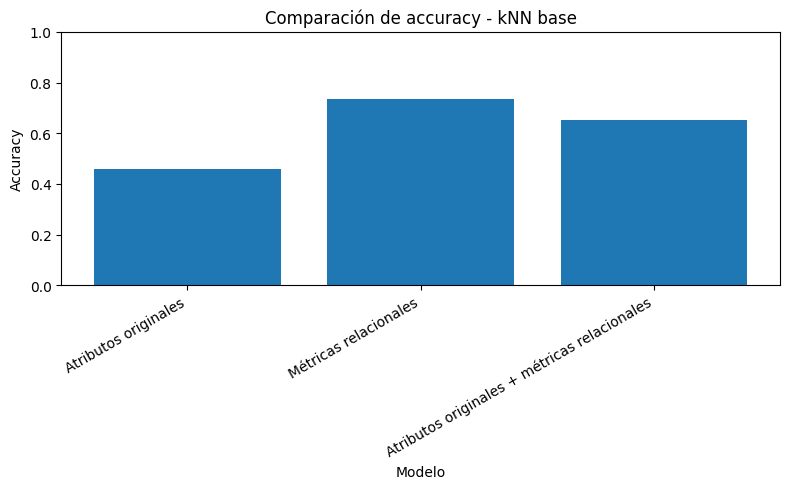

In [84]:
plt.figure(figsize=(8, 5))

plt.bar(resultados_knn['modelo'], resultados_knn['accuracy'])

plt.title('Comparación de accuracy - kNN base')
plt.xlabel('Modelo')
plt.ylabel('Accuracy')

plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig('../reports/knn_comparacion_accuracy_base.png')
plt.show()

### Interpretación de los modelos base

En los modelos base hemos observado diferencias claras entre los tres conjuntos de atributos evaluados con kNN.

El modelo basado únicamente en los atributos originales obtiene un `accuracy` de `0.457565`. Este resultado es bastante bajo en comparación con los otros enfoques. Aunque las palabras contienen información temática útil, en kNN cada artículo se clasifica según la distancia a sus vecinos más cercanos. Al tener muchas columnas binarias de palabras, la distancia entre artículos puede volverse menos informativa, especialmente en un espacio de alta dimensión.

El modelo basado únicamente en métricas relacionales obtiene el mejor resultado base, con un `accuracy` de `0.736162`. Esto indica que la estructura del grafo aporta una señal muy relevante para kNN. En este caso trabajamos con pocas variables, normalizadas y relacionadas directamente con la posición de cada artículo en la red de citaciones, por lo que las distancias entre ejemplos parecen ser más útiles para encontrar vecinos de la misma clase.

El modelo combinado alcanza un `accuracy` de `0.653137`. Aunque mejora al modelo basado solo en palabras, no supera al modelo de métricas relacionales. Esto puede deberse a que, al añadir las 1433 variables binarias de palabras, el espacio de representación crece mucho y las métricas relacionales pierden parte de su influencia dentro del cálculo de distancias.

Por tanto, antes de la optimización, hemos comprobado que para kNN el enfoque más eficaz es utilizar únicamente las métricas relacionales.

## 6. Optimización con Pipeline y GridSearchCV

Para buscar los mejores hiperparámetros del modelo kNN utilizamos `GridSearchCV` . En concreto, distintos valores de:

- `n_neighbors`: número de vecinos utilizados para clasificar.
- `metric`: métrica de distancia utilizada por kNN.

In [85]:
param_grid_knn = {
    'knn__n_neighbors': range(1, 16, 2),
    'knn__metric': ['manhattan', 'euclidean']
}

In [86]:
busqueda_palabras = GridSearchCV(
    modelo_knn_palabras,
    param_grid=param_grid_knn,
    cv=5,
    scoring='accuracy'
)

busqueda_palabras.fit(X_train_palabras, y_train)

y_pred_palabras_opt = busqueda_palabras.predict(X_test_palabras)
accuracy_palabras_opt = accuracy_score(y_test, y_pred_palabras_opt)

print('Mejores parámetros:', busqueda_palabras.best_params_)
print('Accuracy en validación cruzada:', busqueda_palabras.best_score_)
print('Accuracy en test:', accuracy_palabras_opt)

Mejores parámetros: {'knn__metric': 'manhattan', 'knn__n_neighbors': 13}
Accuracy en validación cruzada: 0.47508540777556646
Accuracy en test: 0.47601476014760147


In [87]:
busqueda_metricas = GridSearchCV(
    modelo_knn_metricas,
    param_grid=param_grid_knn,
    cv=5,
    scoring='accuracy'
)

busqueda_metricas.fit(X_train_metricas, y_train)

y_pred_metricas_opt = busqueda_metricas.predict(X_test_metricas)
accuracy_metricas_opt = accuracy_score(y_test, y_pred_metricas_opt)

print('Mejores parámetros:', busqueda_metricas.best_params_)
print('Accuracy en validación cruzada:', busqueda_metricas.best_score_)
print('Accuracy en test:', accuracy_metricas_opt)

Mejores parámetros: {'knn__metric': 'manhattan', 'knn__n_neighbors': 11}
Accuracy en validación cruzada: 0.7470003512095444
Accuracy en test: 0.7343173431734318


In [88]:
busqueda_combinado = GridSearchCV(
    modelo_knn_combinado,
    param_grid=param_grid_knn,
    cv=5,
    scoring='accuracy'
)

busqueda_combinado.fit(X_train_combinado, y_train)

y_pred_combinado_opt = busqueda_combinado.predict(X_test_combinado)
accuracy_combinado_opt = accuracy_score(y_test, y_pred_combinado_opt)

print('Mejores parámetros:', busqueda_combinado.best_params_)
print('Accuracy en validación cruzada:', busqueda_combinado.best_score_)
print('Accuracy en test:', accuracy_combinado_opt)

Mejores parámetros: {'knn__metric': 'manhattan', 'knn__n_neighbors': 9}
Accuracy en validación cruzada: 0.6172763167697236
Accuracy en test: 0.6678966789667896


In [89]:
resultados_knn_optimizados = pd.DataFrame({
    'modelo': [
        'Atributos originales',
        'Métricas relacionales',
        'Atributos originales + métricas relacionales'
    ],
    'accuracy_base': [
        accuracy_palabras,
        accuracy_metricas,
        accuracy_combinado
    ],
    'accuracy_optimizado': [
        accuracy_palabras_opt,
        accuracy_metricas_opt,
        accuracy_combinado_opt
    ],
    'mejora': [
        accuracy_palabras_opt - accuracy_palabras,
        accuracy_metricas_opt - accuracy_metricas,
        accuracy_combinado_opt - accuracy_combinado
    ],
    'mejores_parametros': [
        busqueda_palabras.best_params_,
        busqueda_metricas.best_params_,
        busqueda_combinado.best_params_
    ]
})

resultados_knn_optimizados

,modelo,accuracy_base,accuracy_optimizado,mejora,mejores_parametros
0,Atributos originales,0.457565,0.476015,0.018450,"{'knn__metric': 'manhattan', 'knn__n_neighbors..."
1,Métricas relacionales,0.736162,0.734317,-0.001845,"{'knn__metric': 'manhattan', 'knn__n_neighbors..."
2,Atributos originales + métricas relacionales,0.653137,0.667897,0.014760,"{'knn__metric': 'manhattan', 'knn__n_neighbors..."


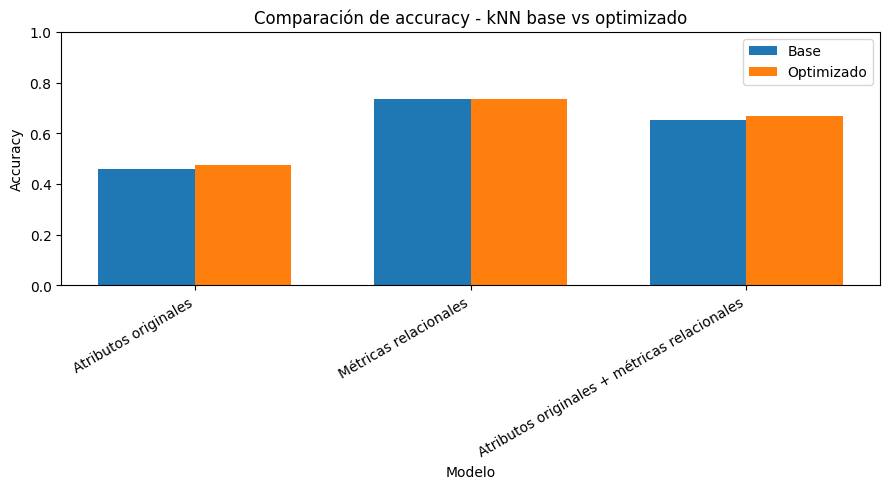

In [90]:
x = np.arange(len(resultados_knn_optimizados))
ancho = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - ancho / 2,
    resultados_knn_optimizados['accuracy_base'],
    width=ancho,
    label='Base'
)

plt.bar(
    x + ancho / 2,
    resultados_knn_optimizados['accuracy_optimizado'],
    width=ancho,
    label='Optimizado'
)

plt.title('Comparación de accuracy - kNN base vs optimizado')
plt.xlabel('Modelo')
plt.ylabel('Accuracy')
plt.xticks(x, resultados_knn_optimizados['modelo'], rotation=30, ha='right')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

plt.savefig('../reports/knn_comparacion_accuracy_optimizado.png')
plt.show()

### Interpretación de la optimización

Con `GridSearchCV` hemos probado distintos valores para el número de vecinos (`n_neighbors`) y para la métrica de distancia (`metric`). En los tres casos, la búsqueda ha seleccionado la distancia `manhattan`, lo que indica que esta métrica se adapta mejor a la representación de nuestros datos que la distancia euclídea usada inicialmente.

En el modelo con atributos originales, el mejor resultado se obtiene con `n_neighbors = 13` y distancia `manhattan`. El `accuracy` pasa de `0.457565` a `0.476015`, con una mejora de `0.018450`. La mejora existe, pero sigue siendo un rendimiento bajo. Esto refuerza la idea de que kNN no aprovecha especialmente bien los atributos binarios de palabras en un espacio tan grande.

En el modelo con métricas relacionales, la mejor configuración es `n_neighbors = 11` y distancia `manhattan`. En este caso, el `accuracy` pasa de `0.736162` a `0.734317`, es decir, baja ligeramente (`-0.001845`). La diferencia es mínima, por lo que podemos considerar que el modelo base ya era una configuración bastante razonable para este conjunto de variables.

En el modelo combinado, la búsqueda selecciona `n_neighbors = 9` y distancia `manhattan`. El `accuracy` mejora de `0.653137` a `0.667897`, con una mejora de `0.014760`. Aun así, el modelo combinado optimizado sigue quedando por debajo del modelo basado únicamente en métricas relacionales.

Por tanto, la optimización mejora ligeramente los modelos de atributos originales y combinado, pero no cambia la conclusión principal: en kNN, las métricas relacionales siguen siendo el conjunto de atributos más eficaz. Además, hemos aplicado la metodología correcta al integrar la normalización y la codificación dentro del `Pipeline`, evitando fuga de datos durante la validación cruzada.

## 7. Conclusiones

En este notebook hemos aplicado kNN siguiendo una metodología comparable a la utilizada en Naive Bayes y coherente con la práctica de `scikit-learn`.

Hemos evaluado tres conjuntos de atributos: atributos originales, métricas relacionales y una combinación de ambos. Para que la comparación fuese justa, hemos utilizado una única partición train/test estratificada para los tres modelos.

También hemos incorporado el preprocesado adecuado para kNN. Como el modelo se basa en distancias, hemos normalizado las variables con `MinMaxScaler`. Además, hemos tratado `louvain_community` como variable categórica mediante `OneHotEncoder` y hemos codificado la clase objetivo con `LabelEncoder`, siguiendo la práctica de `scikit-learn`.

Los resultados muestran que el mejor enfoque para kNN es el modelo basado únicamente en métricas relacionales. Este modelo obtiene un `accuracy` base de `0.736162` y un `accuracy` optimizado de `0.734317`, manteniéndose por encima de los modelos con atributos originales y combinado.

El modelo con atributos originales obtiene el rendimiento más bajo, incluso después de la optimización (`0.476015`). Esto sugiere que las variables binarias de palabras no generan una representación especialmente adecuada para un modelo basado en distancias. Por otro lado, el modelo combinado mejora respecto al uso exclusivo de palabras (`0.667897` optimizado), pero no supera al modelo relacional.

Por tanto, podemos concluir que, para kNN, la información estructural del grafo es más útil que los atributos textuales originales. A diferencia de Naive Bayes, donde el modelo combinado era el mejor, en kNN las métricas relacionales funcionan mejor porque ofrecen una representación más compacta y más adecuada para calcular distancias entre artículos.